## What is an Influence Plot?

An Influence Plot identifies observations that have a large impact on the fitted regression model.

### PART 1 — Basic Influence Plot (Statsmodels Built-in)

This is the standard and correct way.

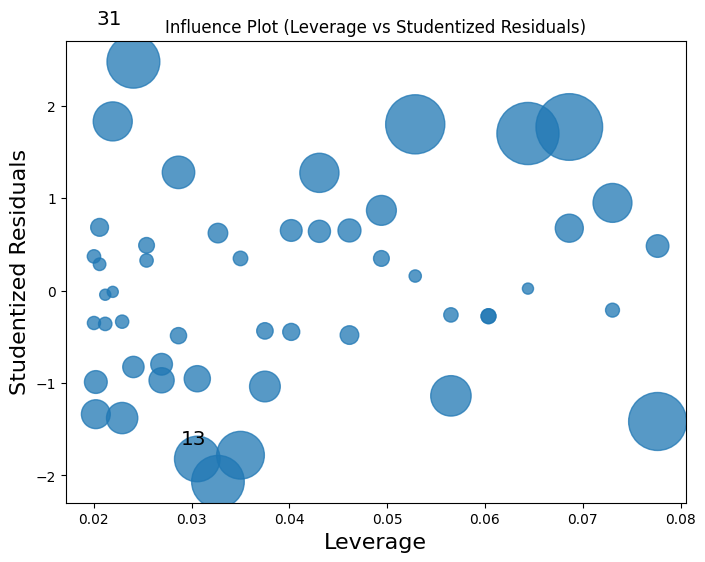

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

np.random.seed(42)

x = np.linspace(0, 10, 50)
y = 3 * x + np.random.normal(0, 3, 50)

df = pd.DataFrame({"X": x, "Y": y})

# Fit model
X = sm.add_constant(df["X"])
model = sm.OLS(df["Y"], X).fit()

# Influence plot
fig, ax = plt.subplots(figsize=(8, 6))
sm.graphics.influence_plot(model, ax=ax, criterion="cooks")

plt.title("Influence Plot (Leverage vs Studentized Residuals)")
plt.show()


### PART 2 — Influence Plot with Labels (Important)

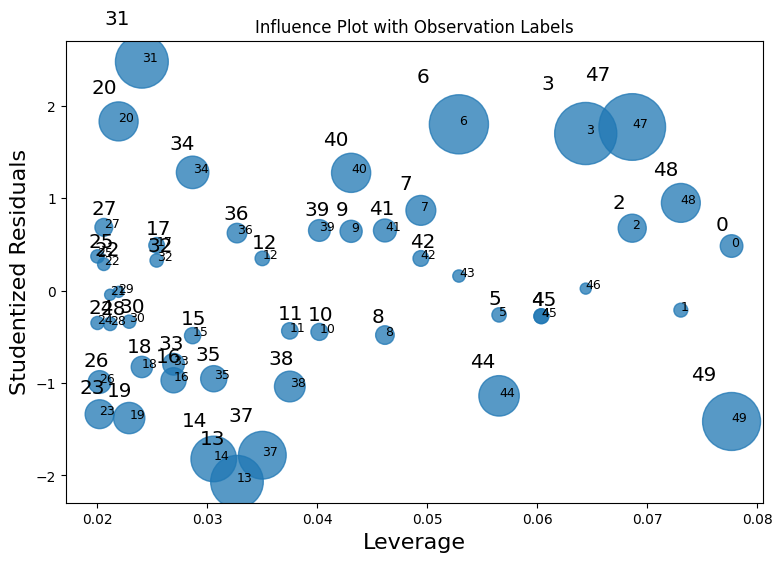

In [2]:
fig, ax = plt.subplots(figsize=(9, 6))

sm.graphics.influence_plot(
    model,
    ax=ax,
    criterion="cooks",
    alpha=0.8
)

for i in range(len(df)):
    ax.text(
        model.get_influence().hat_matrix_diag[i],
        model.get_influence().resid_studentized_external[i],
        str(i),
        fontsize=9
    )

plt.title("Influence Plot with Observation Labels")
plt.show()


### PART 3 — Manual Influence Plot (Fully Custom)

This helps you understand internals clearly.


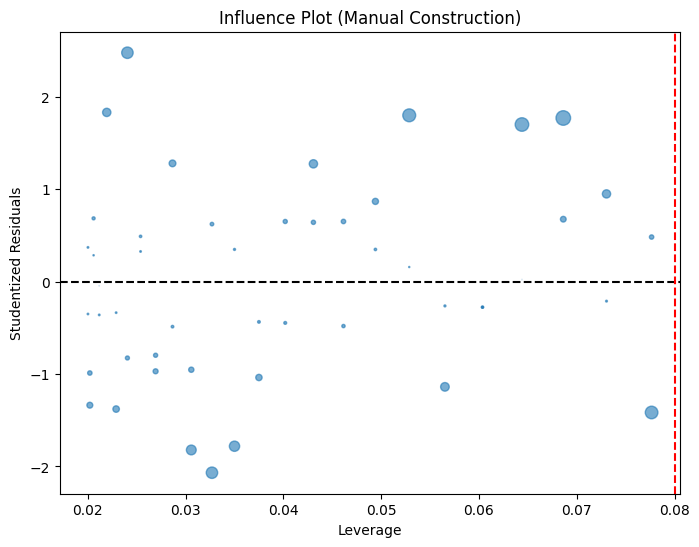

In [3]:
influence = model.get_influence()

leverage = influence.hat_matrix_diag
student_resid = influence.resid_studentized_external
cooks = influence.cooks_distance[0]

plt.figure(figsize=(8, 6))

plt.scatter(
    leverage,
    student_resid,
    s=1000 * cooks,
    alpha=0.6
)

plt.axhline(0, color="black", linestyle="--")
plt.axvline(2 * X.shape[1] / len(df), color="red", linestyle="--")

plt.xlabel("Leverage")
plt.ylabel("Studentized Residuals")
plt.title("Influence Plot (Manual Construction)")

plt.show()


### PART 4 — Add Threshold Lines (Recommended)

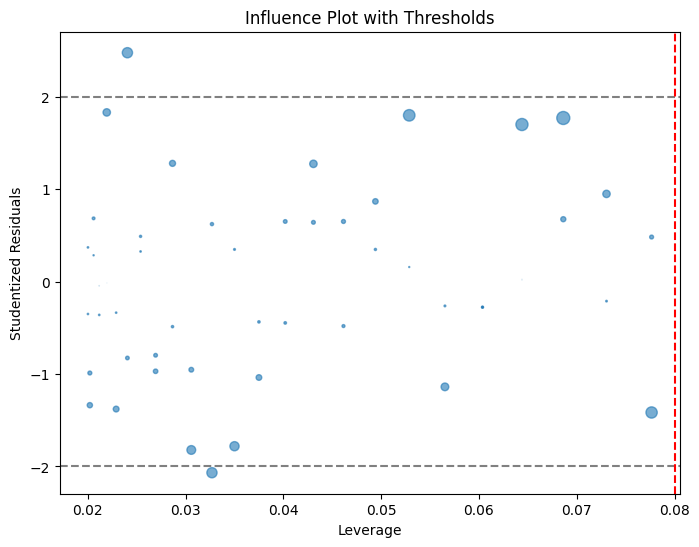

In [4]:
n = len(df)
p = X.shape[1]  # parameters including intercept

threshold = 4 / n

plt.figure(figsize=(8, 6))
plt.scatter(leverage, student_resid, s=800 * cooks, alpha=0.6)

# Thresholds
plt.axhline(2, color="gray", linestyle="--")
plt.axhline(-2, color="gray", linestyle="--")
plt.axvline(2 * p / n, color="red", linestyle="--")

plt.xlabel("Leverage")
plt.ylabel("Studentized Residuals")
plt.title("Influence Plot with Thresholds")
plt.show()


### PART 5 — Highlight Influential Points Automatically

Influential points: [ 3  6 47 49]


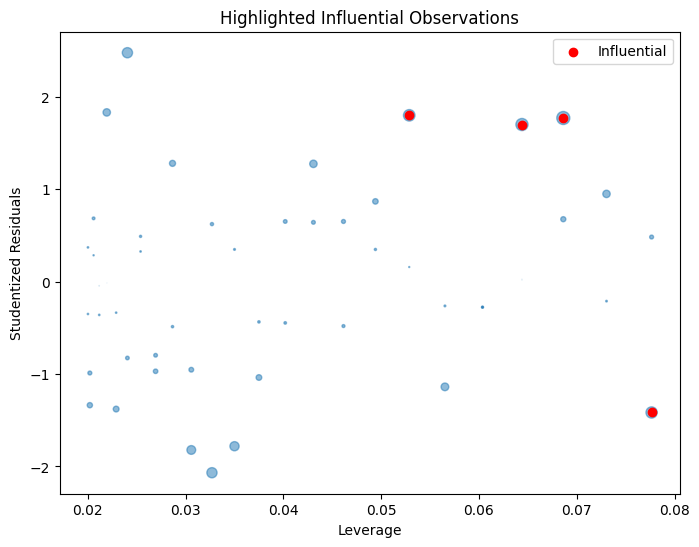

In [5]:
influential = np.where(cooks > 4 / len(df))[0]
print("Influential points:", influential)

plt.figure(figsize=(8, 6))
plt.scatter(leverage, student_resid, s=800 * cooks, alpha=0.5)
plt.scatter(
    leverage[influential],
    student_resid[influential],
    color="red",
    label="Influential"
)

plt.legend()
plt.xlabel("Leverage")
plt.ylabel("Studentized Residuals")
plt.title("Highlighted Influential Observations")
plt.show()


### PART 6 — Influence Plot for Multiple Regression

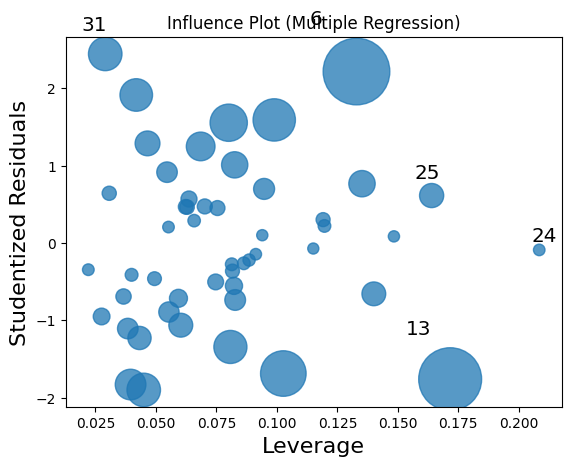

In [6]:
df["X2"] = np.random.normal(0, 1, len(df))
df["X3"] = np.random.normal(3, 1, len(df))

X_multi = sm.add_constant(df[["X", "X2", "X3"]])
model_multi = sm.OLS(df["Y"], X_multi).fit()

sm.graphics.influence_plot(model_multi)
plt.title("Influence Plot (Multiple Regression)")
plt.show()


### PART 7 — Tabular Influence Diagnostics (Very Useful)

In [7]:
infl = model.get_influence()

summary_df = pd.DataFrame({
    "Leverage": infl.hat_matrix_diag,
    "Studentized Residuals": infl.resid_studentized_external,
    "Cooks Distance": infl.cooks_distance[0],
    "DFFITS": infl.dffits[0]
})

summary_df.sort_values("Cooks Distance", ascending=False).head()


,Leverage,Studentized Residuals,Cooks Distance,DFFITS
47,0.068619,1.769060,0.110388,0.480178
3,0.064394,1.698496,0.095526,0.445594
6,0.052869,1.797955,0.086214,0.424791
49,0.077647,-1.415836,0.082647,-0.410797
31,0.024058,2.474974,0.068215,0.388584


### PART 8 — Interpretation Guide (Very Important)

### PART 9 — Typical Threshold Rules


### PART 10 — Full Diagnostic Pipeline

In [8]:
def influence_diagnostics(X, y):
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()
    infl = model.get_influence()

    df_diag = pd.DataFrame({
        "Leverage": infl.hat_matrix_diag,
        "Studentized Residual": infl.resid_studentized_external,
        "CookDistance": infl.cooks_distance[0],
        "DFFITS": infl.dffits[0]
    })

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(
        df_diag["Leverage"],
        df_diag["Studentized Residual"],
        s=800 * df_diag["CookDistance"],
        alpha=0.6
    )
    ax.axhline(0, color="black", linestyle="--")
    ax.set_xlabel("Leverage")
    ax.set_ylabel("Studentized Residuals")
    ax.set_title("Influence Plot")

    plt.show()
    return df_diag


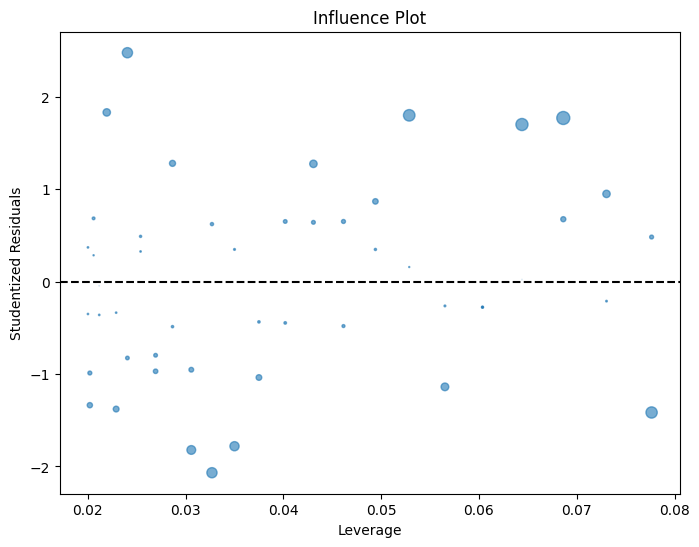

In [9]:
diagnostics = influence_diagnostics(df[["X"]], df["Y"])
